In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score

In [ ]:
df=pd.read_csv('/content/synthetic_house_price_bd.csv')

In [ ]:
df.head()

,Title,Bedrooms,Bathrooms,Floor_no,Occupancy_status,Floor_area,City,Price_in_taka,Location
0,An Apartment Which Is Up For Sale At Firingee ...,3.067509,3.893101,4,vacant,1783.667830,chattogram,"৳5,000,000","Kobi Kazi Nazrul Islam Road, 33 No. Firingee B..."
1,Find 1200 Sq Ft Flat Available For Sale In Pai...,2.769596,3.040837,6,vacant,1627.462726,dhaka,"৳5,500,000","Ahmed Nagar, Mirpur"
2,This Apartment Is Now Vacant For Sale In Momin...,3.166259,3.162834,NaN,NaN,796.119216,chattogram,"৳4,500,000","Ali Nagar, Bayazid"
3,3 Katha Plot is now available for sale in Ashulia,3.208378,3.030825,NaN,NaN,1540.662087,dhaka,"৳4,000,000","Ashulia, Savar"
4,1100 Sq Ft Residential Apartment For Sale In M...,2.567757,3.055072,2,vacant,3594.816314,dhaka,"৳6,700,000","Section 10, Mirpur"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3865 entries, 0 to 3864
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Title             3865 non-null   object 
 1   Bedrooms          2864 non-null   float64
 2   Bathrooms         2864 non-null   float64
 3   Floor_no          3181 non-null   object 
 4   Occupancy_status  3766 non-null   object 
 5   Floor_area        3766 non-null   float64
 6   City              3865 non-null   object 
 7   Price_in_taka     3865 non-null   object 
 8   Location          3859 non-null   object 
dtypes: float64(3), object(6)
memory usage: 271.9+ KB


**Null Treatment**

In [ ]:
df.isnull().sum()

,0
Title,0
Bedrooms,1001
Bathrooms,1001
Floor_no,684
Occupancy_status,99
Floor_area,99
City,0
Price_in_taka,0
Location,6


In [ ]:
df['Bedrooms'].median(), df['Bathrooms'].median(), df['Floor_area'].median()

(2.9805256755897385, 2.9832821658458903, 1446.8917630126784)

In [ ]:
df['Floor_no'].mode()[0], df['Occupancy_status'].mode()[0], df['Location'].mode()[0]

('1', 'vacant', 'Rupganj, Narayanganj')

In [ ]:
treatment={
    'Bedrooms':df['Bedrooms'].median(),
    'Bathrooms':df['Bathrooms'].median(),
    'Floor_area':df['Floor_area'].median(),
    'Floor_no':df['Floor_no'].mode()[0],
    'Occupancy_status':df['Occupancy_status'].mode()[0],
    'Location':df['Location'].mode()[0]
}

In [ ]:
df.fillna(value=treatment, inplace=True)

In [ ]:
df.isnull().sum().sum()

np.int64(0)

**Convert df['Floor_no'] to numeric element**

In [ ]:
df['Floor_no'].value_counts()

,count
Floor_no,
1,1216
4,418
5,402
2,397
3,366
6,316
7,252
8,228
9,167


In [ ]:
garbageFloorNo=[]
for each in df['Floor_no'].value_counts().index:
  try:
    int(each)
  except:
    garbageFloorNo.append(each)

In [ ]:
garbageFloorNo

['Merin City - Purbach',
 '8th',
 '4th to 8th Backside',
 '5th',
 '1st',
 'G+7',
 '0+7',
 '1F',
 'A1,A2,A3,A4,A5,A6,A7']

In [ ]:
for each in df['Floor_no']:
  if each in garbageFloorNo:
    df['Floor_no']=df['Floor_no'].replace(each, df['Floor_no'].value_counts().index[0])

In [ ]:
df['Floor_no'].value_counts()

,count
Floor_no,
1,1232
4,418
5,402
2,397
3,366
6,316
7,252
8,228
9,167


In [ ]:
df['Floor_no']=pd.to_numeric(df['Floor_no'],errors='raise')

**Convert df['Price_in_taka'] to numeric element**

In [ ]:
for each in df['Price_in_taka']:
  temp="";
  for char in each:
    if ((char!='৳') and (char!=',')):
      temp+=char
  df['Price_in_taka']=df['Price_in_taka'].replace(each, temp)

In [ ]:
df.head()

,Title,Bedrooms,Bathrooms,Floor_no,Occupancy_status,Floor_area,City,Price_in_taka,Location
0,An Apartment Which Is Up For Sale At Firingee ...,3.067509,3.893101,4,vacant,1783.667830,chattogram,5000000,"Kobi Kazi Nazrul Islam Road, 33 No. Firingee B..."
1,Find 1200 Sq Ft Flat Available For Sale In Pai...,2.769596,3.040837,6,vacant,1627.462726,dhaka,5500000,"Ahmed Nagar, Mirpur"
2,This Apartment Is Now Vacant For Sale In Momin...,3.166259,3.162834,1,vacant,796.119216,chattogram,4500000,"Ali Nagar, Bayazid"
3,3 Katha Plot is now available for sale in Ashulia,3.208378,3.030825,1,vacant,1540.662087,dhaka,4000000,"Ashulia, Savar"
4,1100 Sq Ft Residential Apartment For Sale In M...,2.567757,3.055072,2,vacant,3594.816314,dhaka,6700000,"Section 10, Mirpur"


In [ ]:
df['Price_in_taka']=pd.to_numeric(df['Price_in_taka'],errors='raise')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3865 entries, 0 to 3864
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Title             3865 non-null   object 
 1   Bedrooms          3865 non-null   float64
 2   Bathrooms         3865 non-null   float64
 3   Floor_no          3865 non-null   int64  
 4   Occupancy_status  3865 non-null   object 
 5   Floor_area        3865 non-null   float64
 6   City              3865 non-null   object 
 7   Price_in_taka     3865 non-null   int64  
 8   Location          3865 non-null   object 
dtypes: float64(3), int64(2), object(4)
memory usage: 271.9+ KB


**Outliers Detection & Handle**

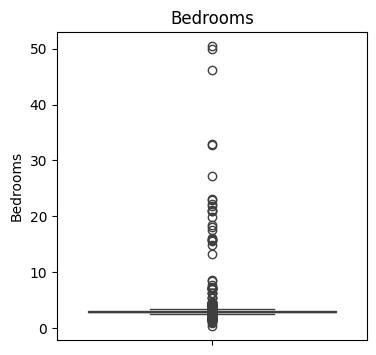

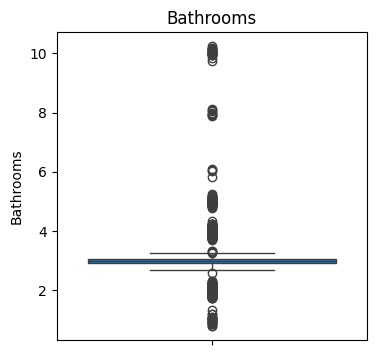

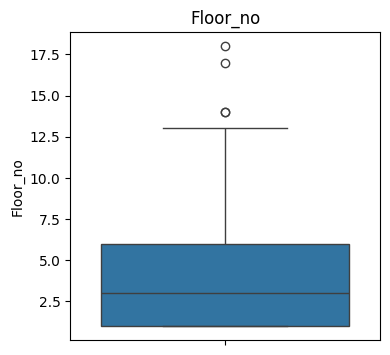

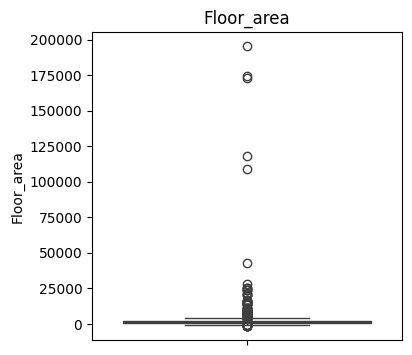

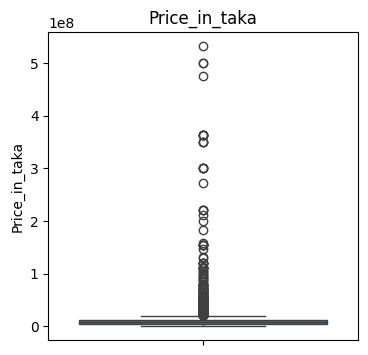

In [ ]:
for each in df.select_dtypes(include='number').columns:
  plt.figure(figsize=(4,4))
  plt.title(each)
  sns.boxplot(data=df[each])
  plt.show()

In [ ]:
for each in df.select_dtypes(include='number').columns:
  q1=df[each].quantile(0.25)
  q3=df[each].quantile(0.75)
  iqr=q3-q1
  lower_bound=q1-1.5*iqr
  upper_bound=q3+1.5*iqr
  temp=df[(df[each]<=lower_bound) | (df[each]>=upper_bound)]
  print(f"Number of outliers in {each} column {len(temp)}")

Number of outliers in Bedrooms column 731
Number of outliers in Bathrooms column 1106
Number of outliers in Floor_no column 4
Number of outliers in Floor_area column 196
Number of outliers in Price_in_taka column 385


In [ ]:
outliers=pd.DataFrame(columns=df.columns)
for each in df.select_dtypes(include='number').columns:
  q1=df[each].quantile(0.25)
  q3=df[each].quantile(0.75)
  iqr=q3-q1
  lower_bound=q1-1.5*iqr
  upper_bound=q3+1.5*iqr
  temp=df[(df[each]<=lower_bound) | (df[each]>=upper_bound)]
  outliers=pd.concat([outliers,temp])

/tmp/ipython-input-3196148676.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  outliers=pd.concat([outliers,temp])


In [ ]:
outliers.duplicated().sum()

np.int64(821)

In [ ]:
outliers.drop_duplicates(inplace=True)

In [ ]:
len(outliers)

1601

In [ ]:
outliers.index

Index([   7,   16,   20,   21,   25,   27,   30,   33,   43,   44,
       ...
       3660, 3668, 3728, 3737, 3750, 3752, 3766, 3785, 3830, 3852],
      dtype='int64', length=1601)

In [ ]:
for each in outliers.index:
  df.drop(index=each, inplace=True)

In [ ]:
len(df)

2264

**Encode Categorical Features**

In [ ]:
df['Occupancy_status'].value_counts()

,count
Occupancy_status,
vacant,2262
occupied,2


In [ ]:
df['City'].value_counts()

,count
City,
dhaka,900
chattogram,887
narayanganj-city,275
gazipur,114
cumilla,88


In [ ]:
df.drop(columns=['Title','Location'],axis=1,inplace=True)

In [ ]:
df=pd.get_dummies(data=df,drop_first=True, dtype=int)

In [ ]:
df.head()

,Bedrooms,Bathrooms,Floor_no,Floor_area,Price_in_taka,Occupancy_status_vacant,City_cumilla,City_dhaka,City_gazipur,City_narayanganj-city
1,2.769596,3.040837,6,1627.462726,5500000,1,0,1,0,0
2,3.166259,3.162834,1,796.119216,4500000,1,0,0,0,0
3,3.208378,3.030825,1,1540.662087,4000000,1,0,1,0,0
4,2.567757,3.055072,2,3594.816314,6700000,1,0,1,0,0
5,2.711508,3.001716,7,561.147856,5700000,1,0,0,0,0


**Feature Scaling**

In [ ]:
features=df.drop(columns='Price_in_taka',axis=1)

In [ ]:
mms=MinMaxScaler()

In [ ]:
mms.fit_transform(features)

array([[0.28645331, 0.61801689, 0.41666667, ..., 1.        , 0.        ,
        0.        ],
       [0.69632616, 0.83512656, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.73984763, 0.60019909, 0.        , ..., 1.        , 0.        ,
        0.        ],
       ...,
       [0.25353982, 0.80472521, 0.33333333, ..., 1.        , 0.        ,
        0.        ],
       [0.9005908 , 0.65835731, 0.        , ..., 0.        , 0.        ,
        1.        ],
       [0.13175267, 0.35654232, 0.66666667, ..., 0.        , 0.        ,
        0.        ]])

In [ ]:
scaledFeatures=pd.DataFrame(mms.fit_transform(features),columns=features.columns)
scaledFeatures

,Bedrooms,Bathrooms,Floor_no,Floor_area,Occupancy_status_vacant,City_cumilla,City_dhaka,City_gazipur,City_narayanganj-city
0,0.286453,0.618017,0.416667,0.531497,1.0,0.0,1.0,0.0,0.0
1,0.696326,0.835127,0.000000,0.356403,1.0,0.0,0.0,0.0,0.0
2,0.739848,0.600199,0.000000,0.513215,1.0,0.0,1.0,0.0,0.0
3,0.077892,0.643350,0.083333,0.945852,1.0,0.0,1.0,0.0,0.0
4,0.226431,0.548396,0.500000,0.306915,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
2259,0.504407,0.515591,0.166667,0.493466,1.0,0.0,1.0,0.0,0.0
2260,0.246464,0.827128,0.250000,0.624659,1.0,0.0,1.0,0.0,0.0
2261,0.253540,0.804725,0.333333,0.516508,1.0,0.0,1.0,0.0,0.0
2262,0.900591,0.658357,0.000000,0.354986,1.0,0.0,0.0,0.0,1.0


**Model Training**

In [ ]:
x=scaledFeatures
y=df['Price_in_taka']

In [ ]:
x.head()

,Bedrooms,Bathrooms,Floor_no,Floor_area,Occupancy_status_vacant,City_cumilla,City_dhaka,City_gazipur,City_narayanganj-city
0,0.286453,0.618017,0.416667,0.531497,1.0,0.0,1.0,0.0,0.0
1,0.696326,0.835127,0.000000,0.356403,1.0,0.0,0.0,0.0,0.0
2,0.739848,0.600199,0.000000,0.513215,1.0,0.0,1.0,0.0,0.0
3,0.077892,0.643350,0.083333,0.945852,1.0,0.0,1.0,0.0,0.0
4,0.226431,0.548396,0.500000,0.306915,1.0,0.0,0.0,0.0,0.0


In [ ]:
y.head()

,Price_in_taka
1,5500000
2,4500000
3,4000000
4,6700000
5,5700000


In [ ]:
xTrain,xTest,yTrain,yTest=train_test_split(x,y,test_size=0.2,random_state=4)

In [ ]:
len(xTrain), len(xTest), len(yTrain), len(yTest)

(1811, 453, 1811, 453)

**Linear Regression**

In [ ]:
model=LinearRegression().fit(xTrain,yTrain)

In [ ]:
model.intercept_

np.float64(10305479.411420112)

In [ ]:
model.coef_

array([ -196412.24894487,    38229.47111416,  1483827.81134516,
        -297927.77613968, -3124971.02637274, -2391829.56035468,
        1257842.77598299, -2789011.10136119,  -958939.59326287])

In [ ]:
model.score(xTrain,yTrain)

0.10354911423428781

In [ ]:
model.score(xTest,yTest)

0.05462302740002012

In [ ]:
r2_score(yTest,model.predict(xTest))

0.05462302740002012

In [ ]:
mean_squared_error(yTest,model.predict(xTest))

14360755204836.564

In [ ]:
mean_absolute_error(yTest,model.predict(xTest))

2846769.5353934355

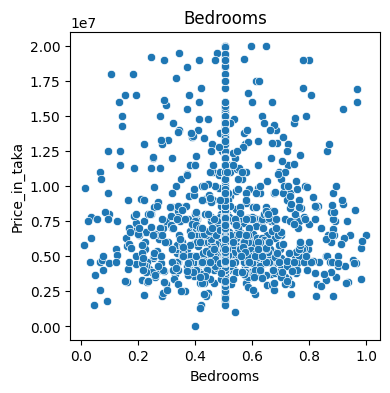

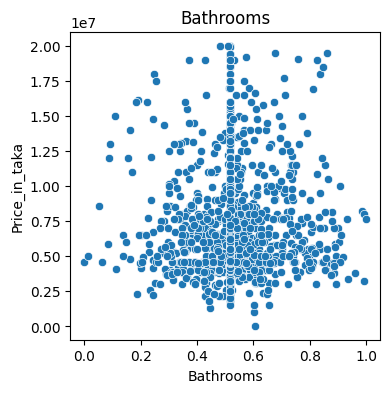

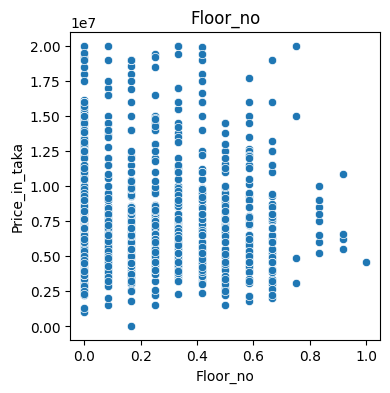

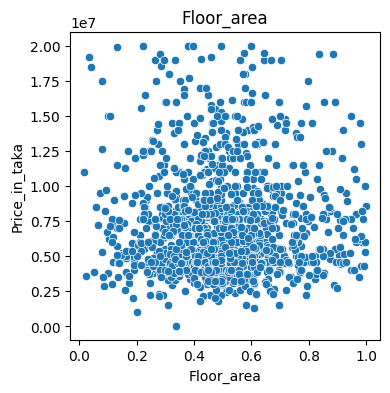

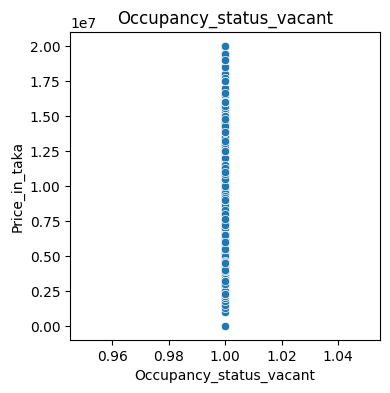

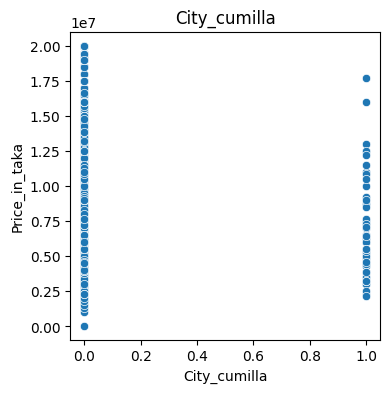

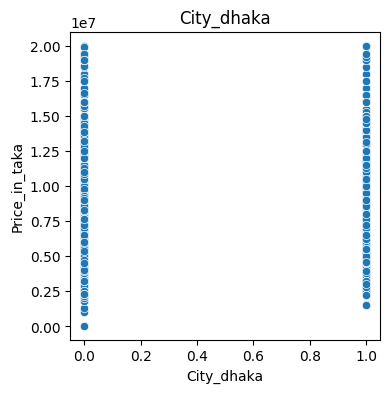

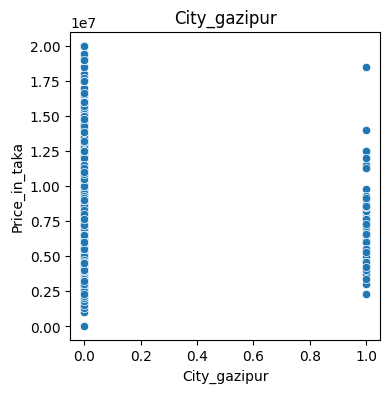

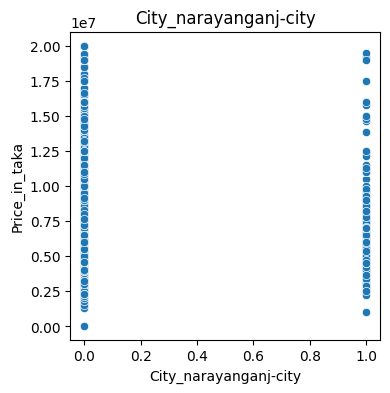

In [ ]:
for each in x:
  plt.figure(figsize=(4,4))
  plt.title(each)
  sns.scatterplot(x=scaledFeatures[each],y=df['Price_in_taka'])
  plt.show()

Since the relation between each feature with the target is not linear, Linear Regression model doesn't work for this dataset

**Feature Selection**

In [ ]:
ForwardFeatureSelector=SequentialFeatureSelector(LinearRegression(),
                                                 k_features=6,
                                                 forward=True,
                                                 verbose=2,
                                                 scoring='r2',
                                                 cv=5).fit(xTrain,yTrain)

[Parallel(n_jobs=1)]: Done   9 out of   9 | elapsed:    0.1s finished

[2026-02-03 06:52:16] Features: 1/6 -- score: 0.057042773094142275[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.1s finished

[2026-02-03 06:52:16] Features: 2/6 -- score: 0.0738419749283088[Parallel(n_jobs=1)]: Done   7 out of   7 | elapsed:    0.1s finished

[2026-02-03 06:52:16] Features: 3/6 -- score: 0.0811037088526334[Parallel(n_jobs=1)]: Done   6 out of   6 | elapsed:    0.1s finished

[2026-02-03 06:52:17] Features: 4/6 -- score: 0.09094218260583024[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.1s finished

[2026-02-03 06:52:17] Features: 5/6 -- score: 0.09632694618126028[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.1s finished

[2026-02-03 06:52:17] Features: 6/6 -- score: 0.09721325696645473

In [ ]:
from sklearn.model_selection import cross_val_score

# Evaluate using negative mean squared error
scores = cross_val_score(
    LinearRegression(),
    xTrain,
    yTrain,
    cv=5,
    scoring='r2'
)

print("Cross-validation scores:", scores)
print("Mean score:", scores.mean())

Cross-validation scores: [0.12519864 0.05135256 0.11462861 0.06008038 0.12787866]
Mean score: 0.09582776841672902


**Lasso Regression**

In [ ]:
Lasso(0.001).fit(xTrain,yTrain).score(xTest,yTest)

0.054006493459296534

In [ ]:
ForwardFeatureSelector=SequentialFeatureSelector(Lasso(0.001),
                                                 k_features=6,
                                                 forward=True,
                                                 verbose=2,
                                                 scoring='r2',
                                                 cv=5).fit(xTrain,yTrain)

[Parallel(n_jobs=1)]: Done   9 out of   9 | elapsed:    0.4s finished

[2026-02-03 06:55:21] Features: 1/6 -- score: 0.05704277309650618[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.3s finished

[2026-02-03 06:55:22] Features: 2/6 -- score: 0.07384197490075255[Parallel(n_jobs=1)]: Done   7 out of   7 | elapsed:    0.3s finished

[2026-02-03 06:55:22] Features: 3/6 -- score: 0.08110370884668797[Parallel(n_jobs=1)]: Done   6 out of   6 | elapsed:    0.3s finished

[2026-02-03 06:55:22] Features: 4/6 -- score: 0.09094218260088596[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.2s finished

[2026-02-03 06:55:22] Features: 5/6 -- score: 0.09632694618223929[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.1s finished

[2026-02-03 06:55:23] Features: 6/6 -- score: 0.09721325696698455

KNN

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
neigh = KNeighborsRegressor(n_neighbors=2)
neigh.fit(xTrain, yTrain)
neigh.score(xTrain,yTrain)

0.5351533934840764

In [ ]:
neigh.score(xTest,yTest)

-0.38029893718298946

In [ ]:
r2_score(yTest,neigh.predict(xTest))

-0.38029893718298946

In [ ]:
ForwardFeatureSelector=SequentialFeatureSelector(KNeighborsRegressor(),
                                                 k_features=6,
                                                 forward=True,
                                                 verbose=2,
                                                 scoring='r2',
                                                 cv=5).fit(xTrain,yTrain)

[Parallel(n_jobs=1)]: Done   9 out of   9 | elapsed:    0.5s finished

[2026-02-03 06:56:26] Features: 1/6 -- score: -0.07831331951088094[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.5s finished

[2026-02-03 06:56:27] Features: 2/6 -- score: -0.06400662063866924[Parallel(n_jobs=1)]: Done   7 out of   7 | elapsed:    0.5s finished

[2026-02-03 06:56:27] Features: 3/6 -- score: -0.05955388848579215[Parallel(n_jobs=1)]: Done   6 out of   6 | elapsed:    0.5s finished

[2026-02-03 06:56:27] Features: 4/6 -- score: -0.056005342210265076[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.4s finished

[2026-02-03 06:56:28] Features: 5/6 -- score: -0.09476048307881575[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.3s finished

[2026-02-03 06:56:28] Features: 6/6 -- score: -0.06909048332220465

**DecisionTree**

In [ ]:
from sklearn import tree
clf = tree.DecisionTreeRegressor()
clf = clf.fit(xTrain, yTrain)
clf.score(xTrain,yTrain)

0.9634164742327301

In [ ]:
clf.score(xTest,yTest)

-1.0122520816242262

In [ ]:
ForwardFeatureSelector=SequentialFeatureSelector(tree.DecisionTreeRegressor(),
                                                 k_features='best',
                                                 forward=True,
                                                 verbose=2,
                                                 scoring='r2',
                                                 cv=5).fit(xTest,yTest)

[Parallel(n_jobs=1)]: Done   9 out of   9 | elapsed:    0.2s finished

[2026-02-03 06:59:11] Features: 1/9 -- score: 0.014345649046384957[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.2s finished

[2026-02-03 06:59:11] Features: 2/9 -- score: 0.027022448843069414[Parallel(n_jobs=1)]: Done   7 out of   7 | elapsed:    0.4s finished

[2026-02-03 06:59:12] Features: 3/9 -- score: 0.03244428913097961[Parallel(n_jobs=1)]: Done   6 out of   6 | elapsed:    0.3s finished

[2026-02-03 06:59:12] Features: 4/9 -- score: 0.03819697568632359[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.3s finished

[2026-02-03 06:59:12] Features: 5/9 -- score: 0.03819697568632359[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.2s finished

[2026-02-03 06:59:12] Features: 6/9 -- score: -0.0121383176319253[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.1s finished

[2026-02-03 06:59:12] Features: 7/9 -- score: -0.7379864221295881[Parallel(n_jobs=1)]: Done   2 out of   2 | el

**SVM**

In [ ]:
from sklearn import svm
regr = svm.SVR()
regr.fit(xTrain, yTrain)
regr.score(xTrain,yTrain)

0.10550427939197993

In [ ]:
regr.score(xTest,yTest)

0.03339690231878556

**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
regr = RandomForestRegressor(max_depth=2, random_state=0)
regr.fit(xTrain, yTrain)
regr.score(xTrain,yTrain)

0.08741246187384677

In [ ]:
regr.score(xTest,yTest)

0.024016444831293282

**ExtraTrees**

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
reg = ExtraTreesRegressor(n_estimators=100, random_state=0).fit(
   xTrain,yTrain)
reg.score(xTrain,yTrain)

0.9634164722768396

In [ ]:
reg.score(xTest,yTest)

-0.18758824105231486

In [ ]:
ForwardFeatureSelector=SequentialFeatureSelector(ExtraTreesRegressor(),
                                                 k_features=6,
                                                 forward=True,
                                                 verbose=2,
                                                 scoring='r2',
                                                 cv=5).fit(xTrain,yTrain)

[Parallel(n_jobs=1)]: Done   9 out of   9 | elapsed:    7.0s finished

[2026-02-03 07:00:47] Features: 1/6 -- score: 0.057042773094142275[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    6.6s finished

[2026-02-03 07:00:53] Features: 2/6 -- score: 0.07384197492830873[Parallel(n_jobs=1)]: Done   7 out of   7 | elapsed:    5.3s finished

[2026-02-03 07:00:59] Features: 3/6 -- score: 0.08110370885263338[Parallel(n_jobs=1)]: Done   6 out of   6 | elapsed:    5.9s finished

[2026-02-03 07:01:05] Features: 4/6 -- score: 0.09094218260583031[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    4.5s finished

[2026-02-03 07:01:09] Features: 5/6 -- score: 0.09398660721124685[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    5.1s finished

[2026-02-03 07:01:14] Features: 6/6 -- score: 0.0950599875779579

**AdaBoost**

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
regr = AdaBoostRegressor(random_state=0, n_estimators=100)
regr.fit(xTrain, yTrain)
regr.score(xTrain,yTrain)

0.04550707415920141

In [ ]:
regr.score(xTest,yTest)

-0.017361904984513954

<Axes: xlabel='Price_in_taka', ylabel='Count'>

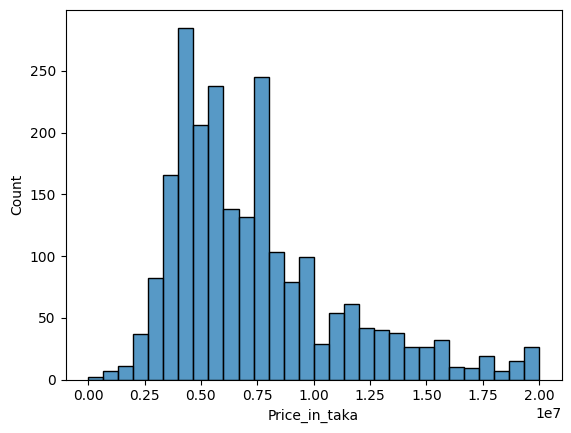

In [ ]:
sns.histplot(data=df['Price_in_taka'])

In [ ]:
df['Price_in_taka'].describe()

,Price_in_taka
count,2.264000e+03
mean,7.474089e+06
std,3.787221e+06
min,6.600000e+01
25%,4.600000e+06
50%,6.500000e+06
75%,9.000000e+06
max,2.000000e+07
